In [ ]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras import regularizers

In [ ]:
img_height = 128
img_width = 128
img_size = (128, 128)
n_classes = 7

base_path = '/content/drive/MyDrive/classification_dataset/projet/dataset_COCO'
train_img_dir = os.path.join(base_path, 'train/data_yolo/images/train')
train_label_dir = os.path.join(base_path, 'train/data_yolo/labels/train')
valid_img_dir = os.path.join(base_path, 'valid/data_yolo/images/valid')
valid_label_dir = os.path.join(base_path, 'valid/data_yolo/labels/valid')

In [ ]:
def get_filenames(label_dir):
    return [f.replace('.txt', '') for f in os.listdir(label_dir) if f.endswith('.txt')]

filenames_train = get_filenames(train_label_dir)
filenames_valid = get_filenames(valid_label_dir)

In [ ]:
def load_image_and_label(filename, img_dir, label_dir):
    # Supprimer l'extension .txt
    base_name = os.path.splitext(filename)[0]

    # Remplacer les noms comme '_mask' s'ils existent
    base_name = base_name.replace("_mask", "")  # correction importante

    img_path = os.path.join(img_dir, base_name + ".jpg")  # ou .png selon le cas

    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found for {filename} in {img_dir}")

    image = tf.io.read_file(img_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = image / 255.0

    # Lecture des labels
    label_path = os.path.join(label_dir, filename)
    with open(label_path, 'r') as f:
        label_indices = [int(line.strip()) for line in f if line.strip().isdigit()]

    label = np.zeros(n_classes)
    label[label_indices] = 1  # multi-hot vector

    return image, label


In [ ]:
def create_dataset(img_dir, label_dir):
    label_files = [f for f in os.listdir(label_dir) if f.endswith(".txt")]

    def generator():
        for fname in label_files:
            yield load_image_and_label(fname, img_dir, label_dir)

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_types=(tf.float32, tf.float32),
        output_shapes=((128, 128, 3), (n_classes,))
    )
    return dataset.shuffle(100).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
train_dataset = create_dataset(train_img_dir, train_label_dir)
val_dataset = create_dataset(valid_img_dir, valid_label_dir)

Instructions for updating:
Use output_signature instead
Instructions for updating:
Use output_signature instead


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(7, activation='sigmoid')  # 7 multilabel classes
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(), tf.keras.metrics.AUC()]
)

In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=8, batch_size=32)

Epoch 1/8
     29/Unknown 80s 3s/step - auc: 0.8471 - binary_accuracy: 0.9027 - loss: 0.2399

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


29/29 ━━━━━━━━━━━━━━━━━━━━ 419s 15s/step - auc: 0.8476 - binary_accuracy: 0.9029 - loss: 0.2394 - val_auc: 0.5224 - val_binary_accuracy: 0.8073 - val_loss: 0.7552
Epoch 2/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 296ms/step - auc: 0.8775 - binary_accuracy: 0.9158 - loss: 0.2213 - val_auc: 0.6320 - val_binary_accuracy: 0.7721 - val_loss: 0.8410
Epoch 3/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 291ms/step - auc: 0.9156 - binary_accuracy: 0.9242 - loss: 0.1887 - val_auc: 0.5998 - val_binary_accuracy: 0.8073 - val_loss: 1.1147
Epoch 4/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 303ms/step - auc: 0.9344 - binary_accuracy: 0.9314 - loss: 0.1650 - val_auc: 0.5970 - val_binary_accuracy: 0.8070 - val_loss: 1.0173
Epoch 5/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 299ms/step - auc: 0.9541 - binary_accuracy: 0.9475 - loss: 0.1371 - val_auc: 0.6016 - val_binary_accuracy: 0.7798 - val_loss: 1.1341
Epoch 6/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 296ms/step - auc: 0.9549 - binary_accuracy: 0.9493 - loss: 0.1331 - val_auc: 0.6296 - val_binary_accurac

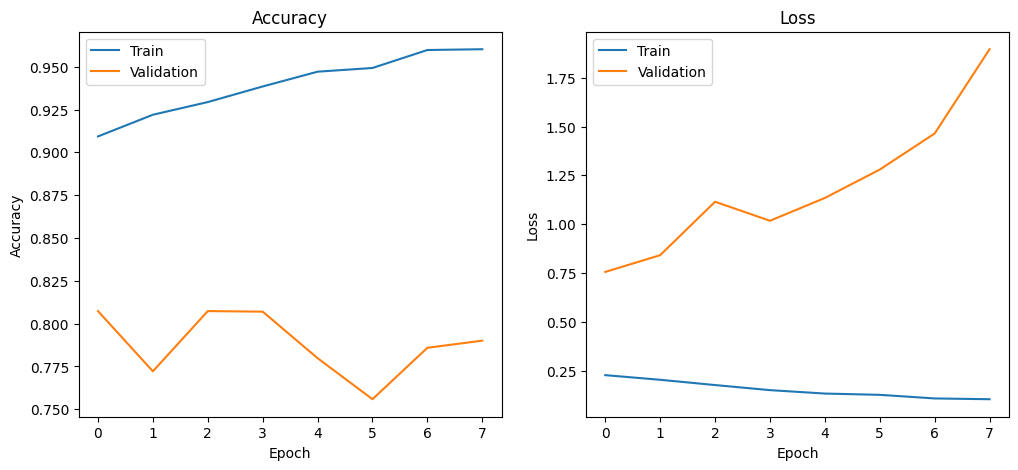

In [ ]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['binary_accuracy'], label='Train')
plt.plot(history.history['val_binary_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Prédire sur le jeu de validation ou test
y_pred = model.predict(val_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)   # classes prédites
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_true_classes = np.argmax(y_true, axis=1)   # classes réelles


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step


In [ ]:
print(classification_report(y_true_classes, y_pred_classes))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        71
           1       0.16      0.59      0.25        63
           2       0.00      0.00      0.00        84
           3       0.27      0.53      0.35       110
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00        98

    accuracy                           0.21       447
   macro avg       0.07      0.19      0.10       447
weighted avg       0.09      0.21      0.12       447



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


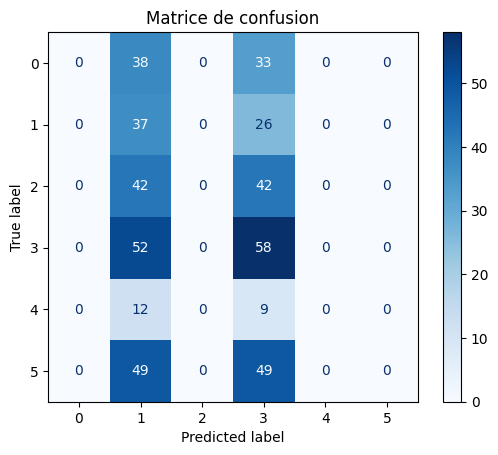

In [ ]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion")
plt.show()
